In [7]:
import glob
import os
import gzip
import scanpy as sc
import anndata as ad

files = glob.glob("../data/*.dem.txt.gz")

adatas = []

print(f"Found {len(files)} patient files to process.")

for filepath in files:
    sample_name = os.path.basename(filepath).replace("dem.txt.gz","")
    print (f"Currently processing {sample_name}...")

    with gzip.open(filepath, "rt") as f:
        adata_sample = sc.read_text(f).T

    adata_sample.obs["sample"] = sample_name

    if "BM" in sample_name:
        adata_sample.obs["Condition"] = "Normal"

    else:
        adata_sample.obs["Condition"] = "AML"

    adatas.append(adata_sample)

print (f"/nMerging all patient files into one main sheet")
adata = ad.concat(adatas, label="sample", join="outer")

adata.var_names_make_unique()
adata.write("../data/combined_raw.h5ad")

print(f"/nSuccesfully created combined_raw.h5ad")

    

Found 43 patient files to process.
Currently processing GSM3588005_OCI-AML3....
Currently processing GSM3587961_AML475-D29....
Currently processing GSM3587973_AML707B-D18....
Currently processing GSM3587990_AML921A-D0....
Currently processing GSM3587940_AML329-D0....
Currently processing GSM3587963_AML556-D0....
Currently processing GSM3587929_AML314-D31....
Currently processing GSM3587946_AML371-D0....
Currently processing GSM3587967_AML556-D31....
Currently processing GSM3587925_AML210A-D0....
Currently processing GSM3587994_AML997-D35....
Currently processing GSM3587986_AML870-D14....
Currently processing GSM3587942_AML329-D20....
Currently processing GSM3588004_MUTZ3....
Currently processing GSM3588003_BM5-34p38n....
Currently processing GSM3587931_AML328-D0....
Currently processing GSM3587997_BM2....
Currently processing GSM3587937_AML328-D29....
Currently processing GSM3587965_AML556-D15....
Currently processing GSM3587923_AML1012-D0....
Currently processing GSM3588002_BM5-34p...

In [12]:
import scanpy as sc

adata = sc.read_h5ad("../data/combined_raw.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 41090 × 27899
    obs: 'sample', 'Condition'


In [6]:
import os
import glob

# 1. Check exactly where your Jupyter notebook is sitting right now
print("1. Current Notebook Location:")
print(os.getcwd())

# 2. Check if Python can see your data folder at all
print("\n2. Checking '../data/' folder presence:")
if os.path.exists("../data"):
    print("✅ Found the '../data' folder!")
    # List everything inside the data folder to see what files are actually in there
    print("\n3. Files actually found inside '../data/':")
    print(os.listdir("../data"))
else:
    print("❌ Cannot find a folder named '../data' relative to this notebook.")

# 4. Check what glob is picking up
print("\n4. Checking glob search:")
print(glob.glob("../data/*.dem.txt.gz"))


1. Current Notebook Location:
/Users/shaharyar/scrna-cancer-project/notebooks

2. Checking '../data/' folder presence:
✅ Found the '../data' folder!

3. Files actually found inside '../data/':
['GSM3588005_OCI-AML3.dem.txt.gz', 'GSM3587972_AML707B-D113.anno.txt.gz', 'GSM3587943_AML329-D20.anno.txt.gz', 'GSM3587961_AML475-D29.dem.txt.gz', 'GSM3587973_AML707B-D18.dem.txt.gz', 'GSM3587983_AML722B-D49.anno.txt.gz', 'GSM3587926_AML210A-D0.anno.txt.gz', 'GSM3587990_AML921A-D0.dem.txt.gz', 'GSM3587940_AML329-D0.dem.txt.gz', 'GSM3587928_AML314-D0.anno.txt.gz', 'GSM3587963_AML556-D0.dem.txt.gz', 'GSM3587929_AML314-D31.dem.txt.gz', 'GSM3587946_AML371-D0.dem.txt.gz', 'GSM3587978_AML707B-D97.anno.txt.gz', 'GSM3587967_AML556-D31.dem.txt.gz', 'GSM3587925_AML210A-D0.dem.txt.gz', 'GSM3587994_AML997-D35.dem.txt.gz', 'GSM3587962_AML475-D29.anno.txt.gz', 'GSM3587941_AML329-D0.anno.txt.gz', 'GSM3587956_AML420B-D14.anno.txt.gz', 'GSM3587986_AML870-D14.dem.txt.gz', 'GSM3587991_AML921A-D0.anno.txt.gz', 'GSM3

Generating Quality Control Violin Plot


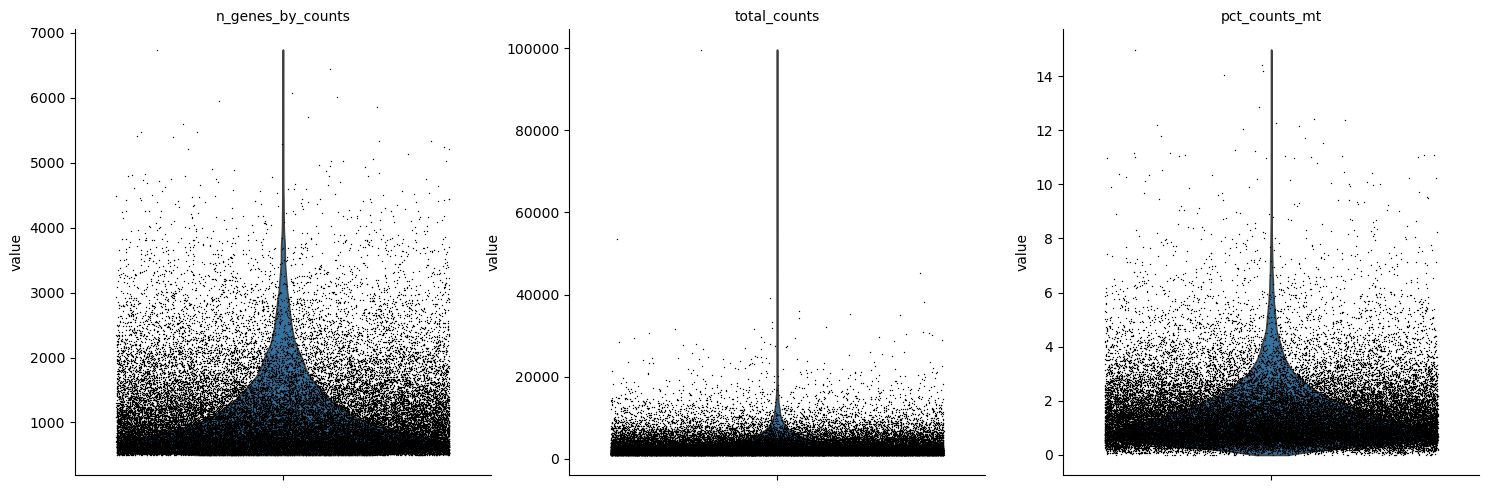

Generating Cell Quality Scatter Plot


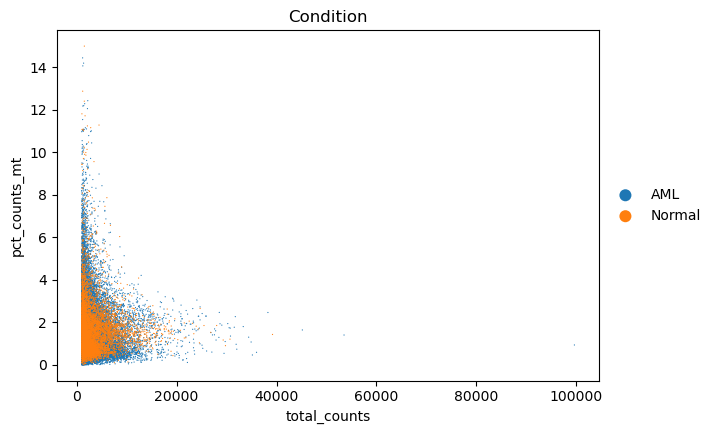

AnnData object with n_obs × n_vars = 41090 × 27899
    obs: 'sample', 'Condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Condition_colors'


In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

print("Generating Quality Control Violin Plot")
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

print("Generating Cell Quality Scatter Plot")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", color="Condition")

print(adata)

In [15]:
print(f"Total cells before filtering: {adata.n_obs}")

sc.pp.filter_cells(adata, min_genes=500)

sc.pp.filter_cells(adata, max_genes=5000)

adata = adata[adata.obs.pct_counts_mt < 5, :]

sc.pp.filter_genes(adata, min_cells=3)

print(f"Total cells after filtering: {adata.n_obs}")

Total cells before filtering: 41067


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Total cells after filtering: 40201


In [18]:
!pip install scrublet

import scrublet as scr

print("Running Scrublet doublet detection across 40,201 cells...")

scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.06)

doublet_scores, predicted_doublets = scrub.scrub_doublets()

adata.obs["doublet_score"] = doublet_scores
adata.obs["predicted_doublets"] = predicted_doublets

num_doublets = adata.obs["predicted_doublets"].sum()
print(f"Scrublet found and flagged {num_doublets} hidden doublets")

adata = adata[~adata.obs["predicted_doublets"]].copy()
print(f"Final clean cell count post-doublet filteration is {adata.n_obs}")

adata.write("../data/combined_raw.h5ad")
print("\n Data has now been saved to ../data/raw_combined_raw.h5ad")

Running Scrublet doublet detection across 40,201 cells...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.79
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 4.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.2%
Elapsed time: 35.1 seconds
Scrublet found and flagged 3 hidden doublets
Final clean cell count post-doublet filteration is 40198

 Data has now been saved to ../data/raw_combined_raw.h5ad


In [21]:
import scanpy as sc
import numpy 

print(f"Current matrix state: {adata.X[0, :5].toarray() if hasattr(adata.X, 'toarray') else adata.X[0, :5]}")

adata.raw = adata

print("\nNormalizing cell count scales...")
sc.pp.normalize_total(adata, target_sum=1e4)

print("Applying Log1p transformation")
sc.pp.log1p(adata)

print(f"\nUpdated matrix state (Normalized and log-scaled): {adata.X[0, :5].toarray() if hasattr(adata.X, 'toarray') else adata.X[0, :5]}")

adata.write("../data/processed_normalized.h5ad")
print("\nProcessed and Normalized data saved to: ../data/processed_normalized.h5ad")



Current matrix state: [0. 0. 0. 0. 0.]

Normalizing cell count scales...
Applying Log1p transformation

Updated matrix state (Normalized and log-scaled): [0. 0. 0. 0. 0.]

Processed and Normalized data saved to: ../data/processed_normalized.h5ad


In [25]:
first_cell_all_genes = adata.X[0, :].flatten()

active_values = first_cell_all_genes[first_cell_all_genes > 0]

print("Actual active normalized numbers in Cell 0:")
print(active_values[:5])

Actual active normalized numbers in Cell 0:
[1.1536268 1.1536268 1.1536268 1.1536268 1.1536268]


In [26]:
print(adata)


AnnData object with n_obs × n_vars = 40198 × 21694
    obs: 'sample', 'Condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublets'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'Condition_colors', 'log1p'


Total genes before variable selection: 21694
Generating Highly Variable Genes Diagnostic Plot


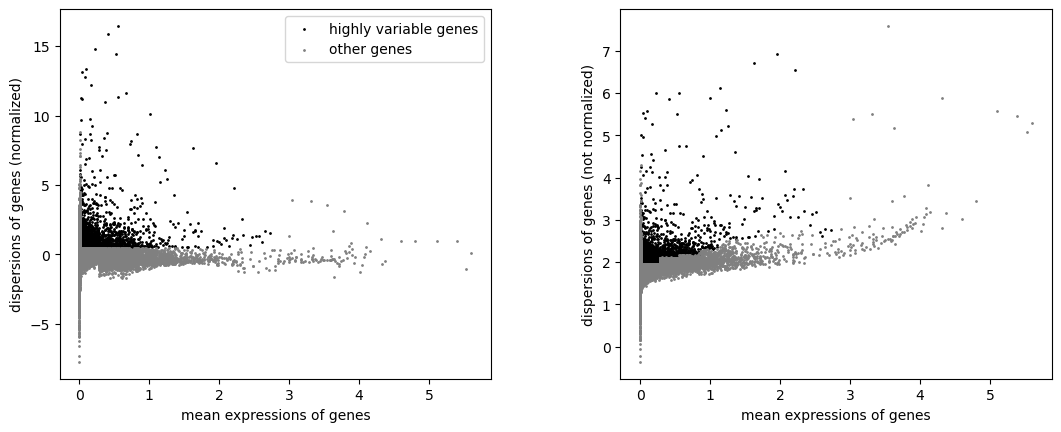

Total genes after variable selection: 3068

HVG_focused dataset safely saved to ../data/processed_HVG.h5ad


In [27]:
import scanpy as sc

print(f"Total genes before variable selection: {adata.n_vars}")

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

print("Generating Highly Variable Genes Diagnostic Plot")
sc.pl.highly_variable_genes(adata)

adata = adata[:, adata.var.highly_variable].copy()

print(f"Total genes after variable selection: {adata.n_vars}")

adata.write("../data/processed_HVG.h5ad")
print("\nHVG_focused dataset safely saved to ../data/processed_HVG.h5ad")


In [2]:
import scanpy as sc

adata = sc.read("../data/processed_HVG.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 40198 × 3068
    obs: 'sample', 'Condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublets'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Condition_colors', 'hvg', 'log1p'


Regressing out technical variations...
Scaling data to unit variance

Running Principal Component Analysis (PCA)...
Building the cell neighborhood graph...
Computing UMAP coordiantes...

Generating your cell cluster variations...


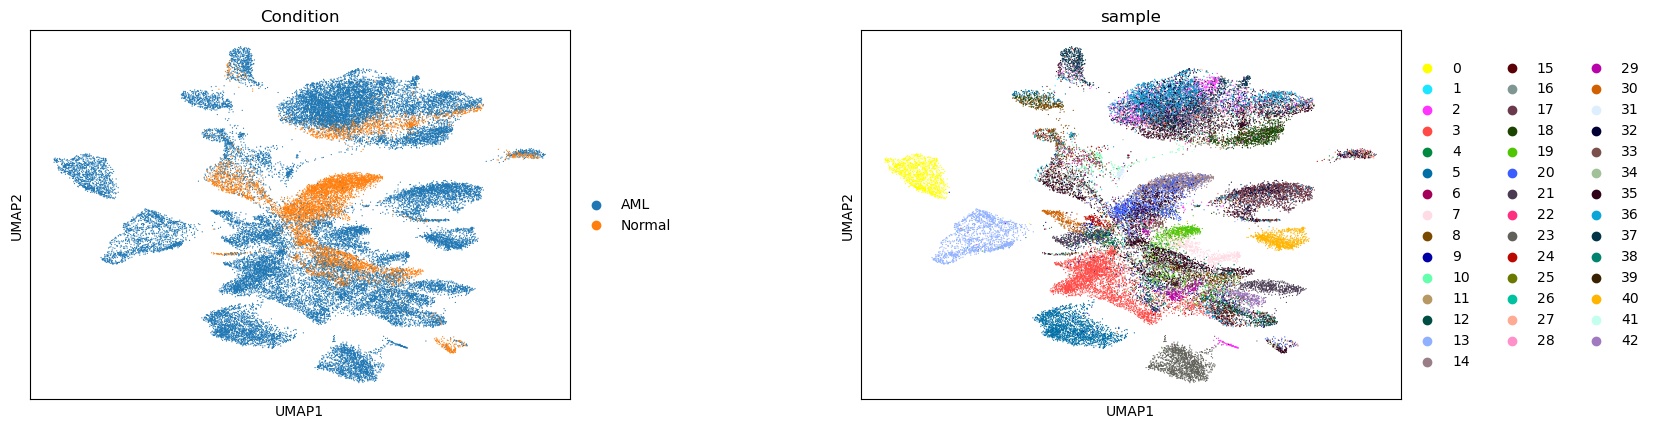


UMAP-mapped coordinates safely saved to ../data/processed_UMAP.h5ad


In [7]:
import scanpy as sc

print("Regressing out technical variations...")
sc.pp.regress_out(adata, ['total_counts'])

print("Scaling data to unit variance")
sc.pp.scale(adata, max_value=10)

print("\nRunning Principal Component Analysis (PCA)...")
sc.tl.pca(adata, svd_solver='arpack')

print("Building the cell neighborhood graph...")
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

print("Computing UMAP coordiantes...")
sc.tl.umap(adata)

print("\nGenerating your cell cluster variations...")
sc.pl.umap(adata, color=['Condition', 'sample'], wspace=0.4)

adata.write("../data/processed_UMAP.h5ad")
print("\nUMAP-mapped coordinates safely saved to ../data/processed_UMAP.h5ad")

In [8]:
import scanpy as sc

adata = sc.read_h5ad("../data/processed_UMAP.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 40198 × 3068
    obs: 'sample', 'Condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublets'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


Running Leiden clustering algorithm...

Cell distribution across clusters:
leiden
0     7098
1     3966
2     3499
3     3016
4     2941
5     2265
6     2046
7     2038
8     2022
9     1692
10    1563
11    1463
12    1308
13    1178
14     903
15     667
16     664
17     619
18     540
19     532
20     178
Name: count, dtype: int64

Generating your UMAP Clustering Map...


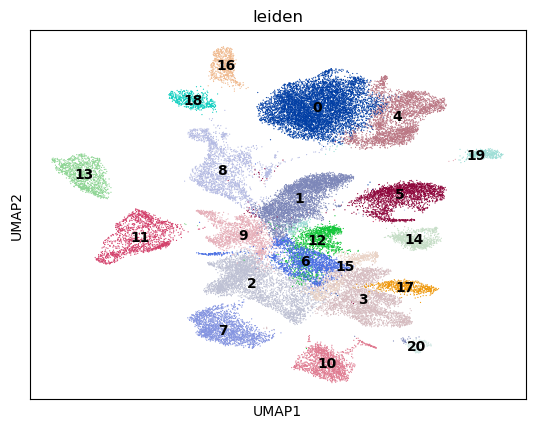


Clustered dataset safely saved to: ../data/processed_clustered.h5ad


In [9]:
import scanpy as sc

print ("Running Leiden clustering algorithm...")
sc.tl.leiden(adata, resolution=0.5)

print("\nCell distribution across clusters:")
print(adata.obs['leiden'].value_counts())

print("\nGenerating your UMAP Clustering Map...")
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

adata.write("../data/processed_clustered.h5ad")
print("\nClustered dataset safely saved to: ../data/processed_clustered.h5ad")

Calculating cluster-specific marker genes...


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanp


Generating your marker gene matrix plot...


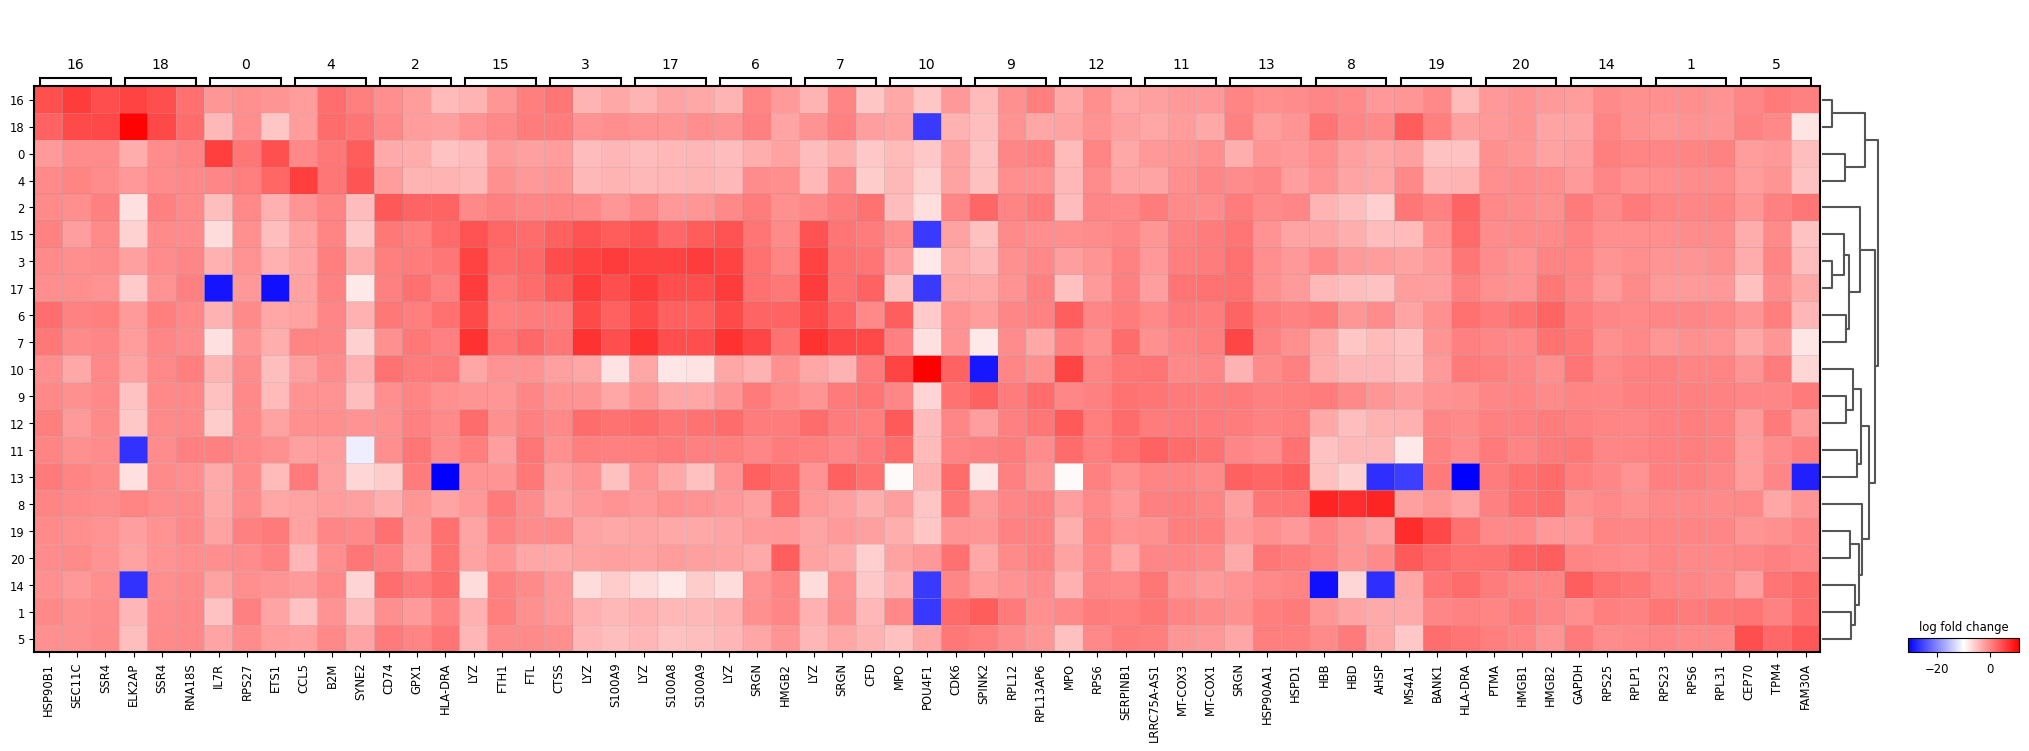


Top 10 marker genes per cluster:


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,IL7R,RPS23,CD74,CTSS,CCL5,CEP70,LYZ,LYZ,HBB,SPINK2,...,LRRC75A-AS1,MPO,SRGN,GAPDH,LYZ,HSP90B1,LYZ,ELK2AP,MS4A1,PTMA
1,RPS27,RPS6,GPX1,LYZ,B2M,TPM4,SRGN,SRGN,HBD,RPL12,...,MT-COX3,RPS6,HSP90AA1,RPS25,FTH1,SEC11C,S100A8,SSR4,BANK1,HMGB1
2,ETS1,RPL31,HLA-DRA,S100A9,SYNE2,FAM30A,HMGB2,CFD,AHSP,RPL13AP6,...,MT-COX1,SERPINB1,HSPD1,RPLP1,FTL,SSR4,S100A9,RNA18S,HLA-DRA,HMGB2
3,B2M,RPS18,TYROBP,FTL,GNLY,H2AFY,HMGB1,APLP2,CA1,PCNP,...,RPL6,YBX1,YBX1,ATP5L,SAT1,SPCS3,FKBP5,MALAT1,MTRNR2,IGLL1
4,CD52,RPL5,RPLP1,PSAP,GZMA,NRIP1,RNASE2,ANXA1,TFRC,LRRC75A-AS1,...,GAS5,ANXA1,HSPA8,TPT1,CTSS,RNA18S,PSAP,RNA28S,CD74,TOP2B
5,RPS29,RPS12,HLA-DPA1,VCAN,HLA-B,ACTG1,AREG,VIM,HMGB1,RPS18P9,...,RPL26,RPS18,NPM1,TMEM123,MALAT1,B2M,VCAN,B2M,RALGPS2,STMN1
6,LTB,RPS3A,HLA-DRB1,S100A8,SYNE1,SEPT6,HMGN2,FTL,BLVRB,RPL13AP5,...,RPS7,ITM2A,HSP90AB1,RPS21,TYROBP,TXNDC5,TXNIP,COMMD3,MALAT1,VPREB1
7,TMSB4X,ZFAS1,HLA-DRB5,MNDA,CALM1,CD34,PTMA,CSTA,HMGB2,CAT,...,TXN,RPS8,HSPE1,RPLP0,PSAP,MZB1,MT-COX1,SEC11C,BIRC3,MME
8,IFITM1,APOOL,CST3,FCN1,PTPRC,GUCY1A3,MNDA,EMB,YBX1,NUCB2,...,RPLP0,DBI,FABP5,FLT3,UBC,SPCS2,CTSS,ANKRD28,CD52,HMGN2
9,IL32,AREG,ACTG1,S100A6,TMSB4X,RPS3,HSP90B1,S100A8,ATPIF1,SERPINB1,...,RPS24,SNHG5,SNRPG,SAP18,CST3,PRDX4,FTL,SEC62,RPS27,MKI67


In [13]:
import scanpy as sc
import pandas as pd

print("Calculating cluster-specific marker genes...")
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test', use_raw=True)

print("\nGenerating your marker gene matrix plot...")
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=3, values_to_plot='logfoldchanges', cmap='bwr')

print("\nTop 10 marker genes per cluster:")
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

In [2]:
import scanpy as sc

adata = sc.read_h5ad("../data/processed_clustered.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 40198 × 3068
    obs: 'sample', 'Condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublets', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [4]:
import pandas as pd

sc.tl.rank_genes_groups(adata, 'leiden', method='t-test', use_raw=True)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

marker_table = pd.DataFrame(adata.uns['rank_genes_groups']['names'])

print("Un-cropped Top 10 Marker Genes for Clusters 0, 1, 2, and 3:")
print(marker_table[['0', '1', '2', '3']].head(10))

Un-cropped Top 10 Marker Genes for Clusters 0, 1, 2, and 3:
        0      1         2       3
0    IL7R  RPS23      CD74    CTSS
1   RPS27   RPS6      GPX1     LYZ
2    ETS1  RPL31   HLA-DRA  S100A9
3     B2M  RPS18    TYROBP     FTL
4    CD52   RPL5     RPLP1    PSAP
5   RPS29  RPS12  HLA-DPA1    VCAN
6     LTB  RPS3A  HLA-DRB1  S100A8
7  TMSB4X  ZFAS1  HLA-DRB5    MNDA
8  IFITM1  APOOL      CST3    FCN1
9    IL32   AREG     ACTG1  S100A6


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanp

Generating final cell-type annotated UMAP...


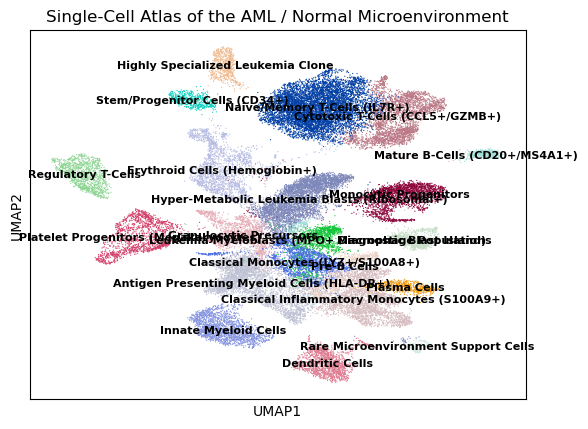


🎉 SUCCESS! Master annotated dataset permanently saved to: ../data/processed_annotated.h5ad


In [7]:
import scanpy as sc

cluster_annotation_map = {
    "0": "Naive/Memory T-Cells (IL7R+)",
    "1": "Hyper-Metabolic Leukemia Blasts (Ribosomal+)",
    "2": "Antigen Presenting Myeloid Cells (HLA-DR+)",
    "3": "Classical Inflammatory Monocytes (S100A9+)",
    "4": "Cytotoxic T-Cells (CCL5+/GZMB+)",
    "5": "Monocytic Progenitors",
    "6": "Classical Monocytes (LYZ+/S100A8+)",
    "7": "Innate Myeloid Cells",
    "8": "Erythroid Cells (Hemoglobin+)",
    "9": "Granulocytic Precursors",
    "10": "Dendritic Cells",
    "11": "Platelet Progenitors (Megakaryocytes)",
    "12": "Leukemia Myeloblasts (MPO+ Diagnostic Blast Island)",
    "13": "Regulatory T-Cells",
    "14": "Macrophage Populations",
    "15": "Pre-B Cells",
    "16": "Highly Specialized Leukemia Clone",
    "17": "Plasma Cells",
    "18": "Stem/Progenitor Cells (CD34+)",
    "19": "Mature B-Cells (CD20+/MS4A1+)",
    "20": "Rare Microenvironment Support Cells"

}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotation_map)

print("Generating final cell-type annotated UMAP...")
sc.pl.umap(
    adata,
    color=['cell_type'],
    legend_loc='on data',
    legend_fontsize=8,
    title='Single-Cell Atlas of the AML / Normal Microenvironment'
)

adata.write("../data/processed_annotated.h5ad")
print("\n🎉 SUCCESS! Master annotated dataset permanently saved to: ../data/processed_annotated.h5ad")